# TP1 · Prétraitement des données Titanic

Ce notebook suit les exigences du TP1 : charger le jeu de données Titanic, le nettoyer, transformer les variables et traiter le déséquilibre des classes avant la modélisation.

## Plan du notebook
- **Partie 1** : Charger Titanic, inspecter les types, prévisualiser les données et résumer les valeurs manquantes.
- **Partie 2** : Nettoyer les données en traitant les valeurs manquantes et les valeurs extrêmes.
- **Partie 3** : Encoder les variables catégorielles, mettre à l'échelle les variables numériques et visualiser les distributions.
- **Partie 4** : Diagnostiquer et corriger le déséquilibre de la cible avec sous-échantillonnage et SMOTE.

In [35]:
# Bibliothèques principales
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Utilitaires scikit-learn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.utils import resample

# Imbalanced-learn (avec repli automatique si incompatibilité de versions)
try:
    from imblearn.over_sampling import SMOTE as _SMOTE

    class SMOTE(_SMOTE):
        pass
except Exception as exc:
    warnings.warn(
        "SMOTE (imblearn) indisponible ou incompatible. "
        "Repli activé: sur-échantillonnage aléatoire.",
        RuntimeWarning,
    )

    class SMOTE:
        """Repli minimal compatible avec l'API fit_resample de SMOTE."""

        def __init__(self, random_state=42):
            self.random_state = random_state

        def fit_resample(self, X, y):
            X_df = pd.DataFrame(X).copy()
            y_sr = pd.Series(y).copy().reset_index(drop=True)
            X_df = X_df.reset_index(drop=True)

            counts = y_sr.value_counts()
            if counts.shape[0] < 2:
                return X_df, y_sr

            minority_class = counts.idxmin()
            majority_class = counts.idxmax()
            n_to_add = int(counts[majority_class] - counts[minority_class])
            if n_to_add <= 0:
                return X_df, y_sr

            minority_idx = y_sr[y_sr == minority_class].index
            sampled_idx = np.random.default_rng(self.random_state).choice(
                minority_idx, size=n_to_add, replace=True
            )

            X_new = pd.concat([X_df, X_df.loc[sampled_idx]], ignore_index=True)
            y_new = pd.concat(
                [y_sr, pd.Series([minority_class] * n_to_add)],
                ignore_index=True,
            )
            return X_new, y_new

# Réglages généraux
sns.set_theme(style="whitegrid")

C:\Users\Home\AppData\Local\Temp\ipykernel_18196\1948883253.py:20: RuntimeWarning: SMOTE (imblearn) indisponible ou incompatible. Repli activé: sur-échantillonnage aléatoire.
  warnings.warn(


In [36]:
# Partie 1 : Chargement et inspection du jeu de données Titanic
raw_df = sns.load_dataset("titanic")
rename_map = {
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
    "embarked": "Embarked",
    "class": "Class",
    "who": "Who",
    "adult_male": "AdultMale",
    "deck": "Deck",
    "embark_town": "EmbarkTown",
    "alive": "Alive",
    "alone": "Alone"
}
df = raw_df.rename(columns=rename_map).copy()
print(f"Dimensions du jeu de données : {df.shape}")
print("\nTypes de données :")
display(df.dtypes)
print("\nPremières lignes :")
display(df.head())
print("\nValeurs manquantes par colonne :")
display(df.isnull().sum())

Dimensions du jeu de données : (891, 15)

Types de données :


Survived         int64
Pclass           int64
Sex             object
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked        object
Class         category
Who             object
AdultMale         bool
Deck          category
EmbarkTown      object
Alive           object
Alone             bool
dtype: object


Premières lignes :


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,AdultMale,Deck,EmbarkTown,Alive,Alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Valeurs manquantes par colonne :


Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked        2
Class           0
Who             0
AdultMale       0
Deck          688
EmbarkTown      2
Alive           0
Alone           0
dtype: int64

## Partie 2 · Nettoyage des données
Étapes : (1) repérer les colonnes très lacunaires (>40 % et suppression), (2) imputer les colonnes numériques par la médiane, (3) imputer les colonnes catégorielles par la modalité dominante, (4) repérer et corriger les valeurs extrêmes via la médiane.

In [37]:
# Suivi des valeurs manquantes et suppression des colonnes >40 % de NaN
df_clean = df.copy()
missing_ratio = df_clean.isnull().mean().sort_values(ascending=False)
print("Proportion de valeurs manquantes par colonne :")
display(missing_ratio.to_frame(name="ratio"))
cols_to_drop = missing_ratio[missing_ratio > 0.40].index.tolist()
print(f"\nColonnes supprimées (>40 % manquantes) : {cols_to_drop}")
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Forme restante : {df_clean.shape}")

Proportion de valeurs manquantes par colonne :


,ratio
Deck,0.772166
Age,0.198653
Embarked,0.002245
EmbarkTown,0.002245
Survived,0.000000
Pclass,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Fare,0.000000



Colonnes supprimées (>40 % manquantes) : ['Deck']
Forme restante : (891, 14)


In [38]:
# Imputation : médiane pour le numérique, mode pour le catégoriel
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
for col in categorical_cols:
    mode_val = df_clean[col].mode(dropna=True)
    if not mode_val.empty:
        df_clean[col].fillna(mode_val.iloc[0], inplace=True)
print("Valeurs manquantes restantes par colonne :")
print(df_clean.isnull().sum())

Valeurs manquantes restantes par colonne :
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Class         0
Who           0
AdultMale     0
EmbarkTown    0
Alive         0
Alone         0
dtype: int64


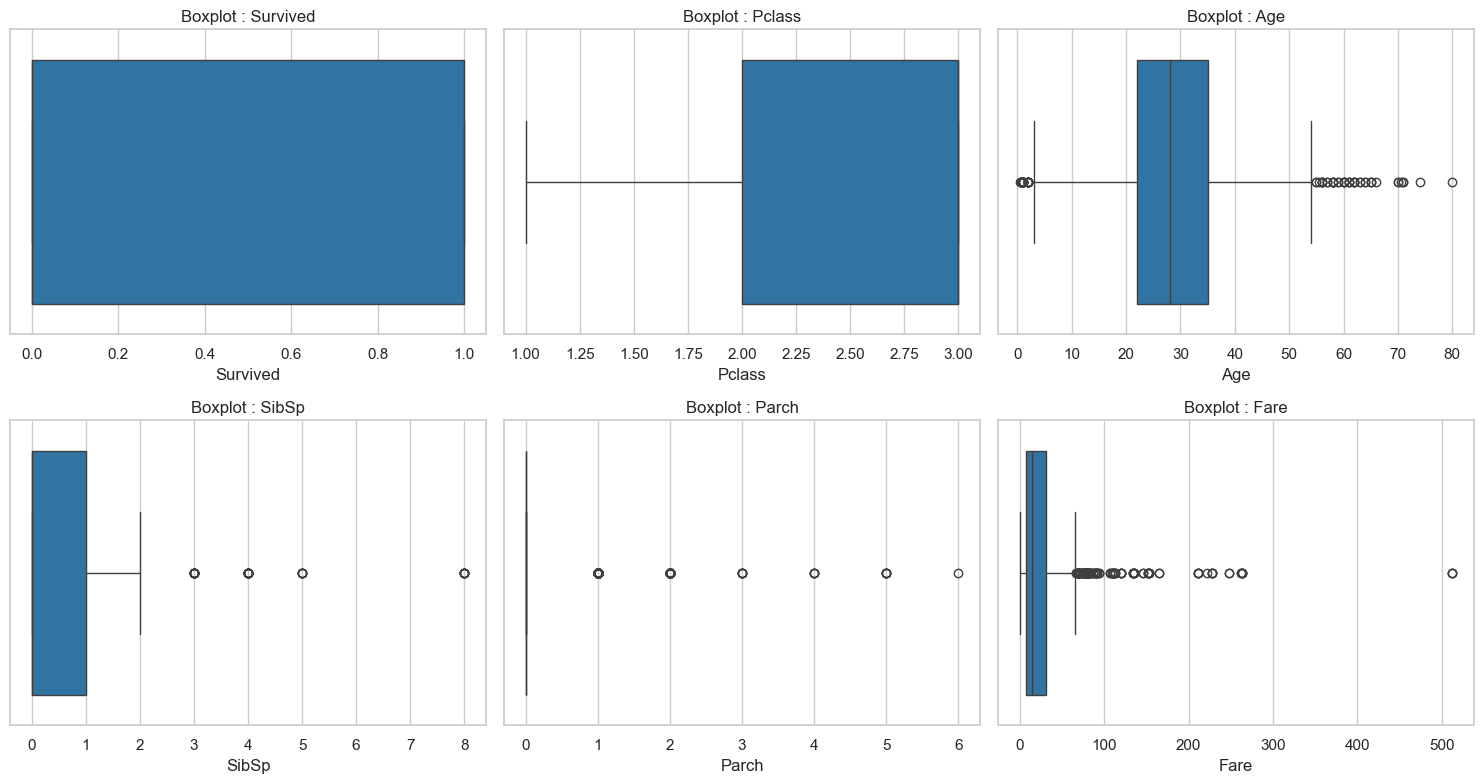

In [39]:
# Visualisation des valeurs extrêmes via boxplots
num_plots = len(numeric_cols)
cols = 3
rows = int(np.ceil(num_plots / cols))
plt.figure(figsize=(cols * 5, rows * 4))
for idx, col in enumerate(numeric_cols, start=1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=df_clean[col], color="#1f77b4")
    plt.title(f"Boxplot : {col}")
plt.tight_layout()
plt.show()

In [40]:
# Remplacement des valeurs extrêmes (au-delà de 1,5 IQR) par la médiane
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    median_val = df_clean[col].median()
    mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    replaced = mask.sum()
    df_clean.loc[mask, col] = median_val
    print(f"{col} : {replaced} valeurs extrêmes remplacées par la médiane")

Survived : 0 valeurs extrêmes remplacées par la médiane
Pclass : 0 valeurs extrêmes remplacées par la médiane
Age : 66 valeurs extrêmes remplacées par la médiane
SibSp : 46 valeurs extrêmes remplacées par la médiane
Fare : 116 valeurs extrêmes remplacées par la médiane


## Partie 3 · Transformation des données
Nous encodons les variables catégorielles, mettons à l'échelle les variables numériques (Min-Max et Z-score) et observons l'évolution des distributions.

In [41]:
# Encodage One-Hot des variables nominales (Pclass reste ordinale)
target_col = "Survived"
categorical_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
nominal_cols = categorical_cols.copy()
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)
print(f"Dimensions après encodage : {df_encoded.shape}")
display(df_encoded.head())

Dimensions après encodage : (891, 18)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Class_Second,Class_Third,Who_man,Who_woman,AdultMale_True,EmbarkTown_Queenstown,EmbarkTown_Southampton,Alive_yes,Alone_True
0,0,3,22.0,1,0,7.2500,True,False,True,False,True,True,False,True,False,True,False,False
1,1,1,38.0,1,0,14.4542,False,False,False,False,False,False,True,False,False,False,True,False
2,1,3,26.0,0,0,7.9250,False,False,True,False,True,False,True,False,False,True,True,True
3,1,1,35.0,1,0,53.1000,False,False,True,False,False,False,True,False,False,True,True,False
4,0,3,35.0,0,0,8.0500,True,False,True,False,True,True,False,True,False,True,False,True


In [42]:
# Normalisation Min-Max et standardisation (Z-score) des variables numériques
num_features = [col for col in df_clean.select_dtypes(include=[np.number]).columns if col != target_col]
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
df_minmax = df_clean.copy()
df_standard = df_clean.copy()
df_minmax[num_features] = minmax_scaler.fit_transform(df_minmax[num_features])
df_standard[num_features] = standard_scaler.fit_transform(df_standard[num_features])
display(df_minmax.head())
display(df_standard.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,AdultMale,EmbarkTown,Alive,Alone
0,0,1.0,male,0.372549,0.5,0.0,0.111538,S,Third,man,True,Southampton,no,False
1,1,0.0,female,0.686275,0.5,0.0,0.222372,C,First,woman,False,Cherbourg,yes,False
2,1,1.0,female,0.450980,0.0,0.0,0.121923,S,Third,woman,False,Southampton,yes,True
3,1,0.0,female,0.627451,0.5,0.0,0.816923,S,First,woman,False,Southampton,yes,False
4,0,1.0,male,0.627451,0.0,0.0,0.123846,S,Third,man,True,Southampton,no,True


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Class,Who,AdultMale,EmbarkTown,Alive,Alone
0,0,0.827377,male,-0.661724,1.347605,-0.473674,-0.797554,S,Third,man,True,Southampton,no,False
1,1,-1.566107,female,0.972921,1.347605,-0.473674,-0.230556,C,First,woman,False,Cherbourg,yes,False
2,1,0.827377,female,-0.253063,-0.570472,-0.473674,-0.744429,S,Third,woman,False,Southampton,yes,True
3,1,-1.566107,female,0.666425,1.347605,-0.473674,2.811012,S,First,woman,False,Southampton,yes,False
4,0,0.827377,male,0.666425,-0.570472,-0.473674,-0.734591,S,Third,man,True,Southampton,no,True


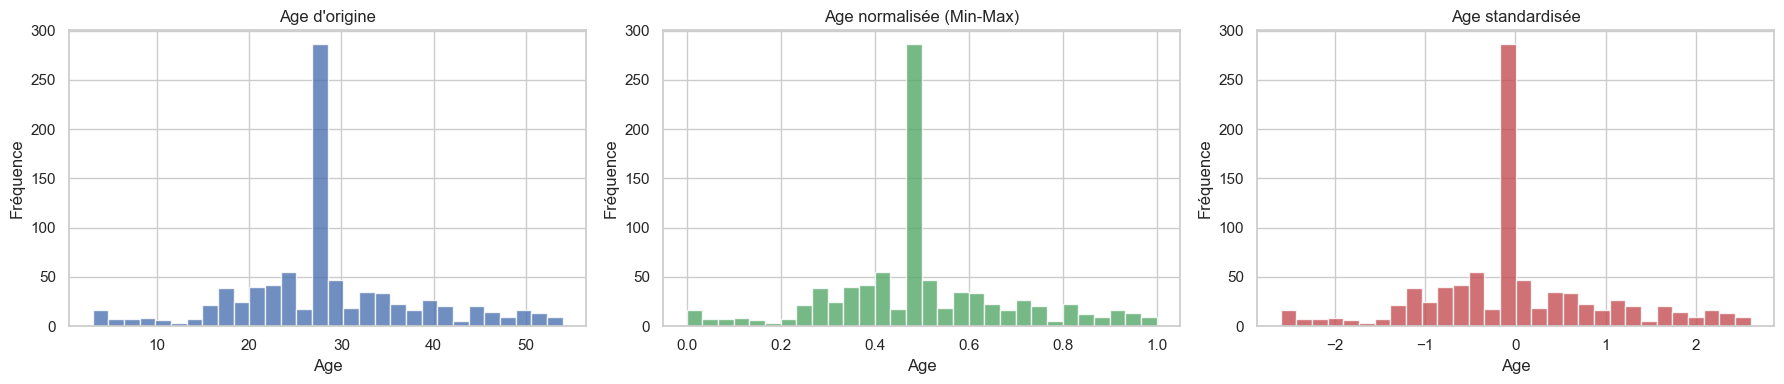

In [43]:
# Comparaison des distributions avant/après mise à l'échelle pour une variable représentative
feature_to_plot = "Age" if "Age" in df_clean.columns else num_features[0]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df_clean[feature_to_plot], bins=30, color="#4c72b0", alpha=0.8)
axes[0].set_title(f"{feature_to_plot} d'origine")
axes[1].hist(df_minmax[feature_to_plot], bins=30, color="#55a868", alpha=0.8)
axes[1].set_title(f"{feature_to_plot} normalisée (Min-Max)")
axes[2].hist(df_standard[feature_to_plot], bins=30, color="#c44e52", alpha=0.8)
axes[2].set_title(f"{feature_to_plot} standardisée")
for ax in axes:
    ax.set_xlabel(feature_to_plot)
    ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.show()

## Partie 4 · Gestion du déséquilibre
Nous inspectons la balance de la cible, puis appliquons un sous-échantillonnage et SMOTE (sur-échantillonnage synthétique) sur la matrice encodée.

Survived
0    549
1    342
Name: count, dtype: int64


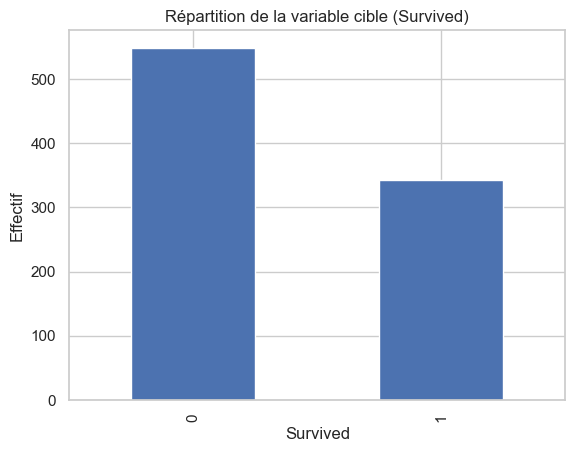

In [44]:
# Vérification de la balance de la variable cible
print(df_clean[target_col].value_counts())
df_clean[target_col].value_counts().plot(kind="bar", title="Répartition de la variable cible (Survived)")
plt.xlabel("Survived")
plt.ylabel("Effectif")
plt.show()

In [45]:
# Sous-échantillonnage de la classe majoritaire
df_majority = df_encoded[df_encoded[target_col] == 0]
df_minority = df_encoded[df_encoded[target_col] == 1]
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)
df_undersampled = pd.concat([df_majority_downsampled, df_minority])
print("Répartition après sous-échantillonnage :")
print(df_undersampled[target_col].value_counts())

Répartition après sous-échantillonnage :
Survived
0    342
1    342
Name: count, dtype: int64


In [46]:
# Sur-échantillonnage avec SMOTE
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("Répartition équilibrée via SMOTE :")
print(pd.Series(y_smote).value_counts())

Répartition équilibrée via SMOTE :
0    549
1    549
Name: count, dtype: int64


### Bilan
Le notebook couvre désormais l'ensemble du flux de prétraitement : chargement, nettoyage, encodage, mise à l'échelle et équilibrage du jeu de données Titanic, prêt pour les expériences de modélisation.